In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'asl-alphabet' dataset.
Path to dataset files: /kaggle/input/asl-alphabet


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir("/kaggle/input/asl-alphabet"))

['asl_alphabet_test', 'asl_alphabet_train']


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [ ]:
import os

train_dir = os.path.join(path, 'asl_alphabet_train')
print(os.listdir(train_dir))

['asl_alphabet_train']


In [ ]:
dataset_path = "/content/drive/MyDrive/archive/asl_alphabet_train/asl_alphabet_train"


In [ ]:
img_size = 64
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 60091 images belonging to 29 classes.
Found 15020 images belonging to 29 classes.


final


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import LSTM, Reshape
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [ ]:
dataset_path = "/content/drive/MyDrive/archive/asl_alphabet_train/asl_alphabet_train"

In [ ]:
img_size = 64
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 60091 images belonging to 29 classes.
Found 15020 images belonging to 29 classes.


In [ ]:
model = Sequential()

# CNN Feature Extraction
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten Features
model.add(Flatten())

# Convert Features into Sequence
# Corrected reshape: (6*6*128) = 4608 elements. If features are 128, then timesteps = 4608/128 = 36.
model.add(Reshape((36, 128)))

# LSTM Layer
model.add(LSTM(128))

# Dense Layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(train_data.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 36, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,309 (1.01 MB)

 Trainable params: 265,309 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 19271s 10s/step - accuracy: 0.6033 - loss: 1.2300 - val_accuracy: 0.6919 - val_loss: 0.9743
Epoch 2/20
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 548s 292ms/step - accuracy: 0.9497 - loss: 0.1570 - val_accuracy: 0.8047 - val_loss: 0.9217
Epoch 3/20
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 521s 277ms/step - accuracy: 0.9804 - loss: 0.0640 - val_accuracy: 0.8423 - val_loss: 0.8297
Epoch 4/20
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 520s 277ms/step - accuracy: 0.9847 - loss: 0.0531 - val_accuracy: 0.8411 - val_loss: 0.8019
Epoch 5/20
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 521s 277ms/step - accuracy: 0.9890 - loss: 0.0377 - val_accuracy: 0.8642 - val_loss: 0.8410
Epoch 6/20
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 582s 310ms/step - accuracy: 0.9890 - loss: 0.0396 - val_accuracy: 0.8458 - val_loss: 0.7904
Epoch 7/20
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 623s 332ms/step - accuracy: 0.9934 - loss: 0.0236 - val_accuracy: 0.8614 - val_loss: 0.7991
Epoch 8/20
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 634s 337ms/step - ac

In [ ]:
model.save("cnn_lstm_sign_language_model.keras")

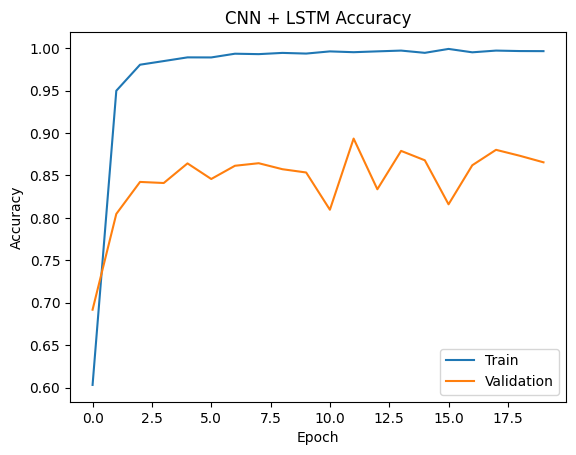

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("CNN + LSTM Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
model.save("/content/drive/MyDrive/cnn_lstm_sign_language_model.keras")